# Phase 2 — Exploratory Data Analysis
## Financial News Sentiment Intelligence System

**Goal:** Systematically investigate the raw dataset to understand
its structure, quality, and patterns — and produce documented
findings that directly inform our modelling decisions.

**Input:** `data/raw/all_news.csv`
**Output:** `data/processed/news_clean.csv` + 4 charts in `reports/figures/`

---
**The 6-layer EDA framework used here:**
1. Structural analysis — shape, types, nulls, duplicates
2. Univariate analysis — each column in isolation
3. Bivariate analysis — relationships between columns
4. Text analysis — word frequency, headline patterns
5. Temporal analysis — patterns over time
6. Clean + save — apply findings, produce processed data

In [4]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from config import RAW_DATA_PATH, PROCESSED_DATA_PATH
from src.eda import (
    structural_summary,
    check_duplicates,
    plot_article_distribution,
    plot_coverage_heatmap,
    compute_text_stats,
    plot_word_frequency,
    plot_temporal_patterns,
    clean_and_save,
)
from src.utils import get_logger
logger = get_logger("02_eda")

# load raw data
df = pd.read_csv(RAW_DATA_PATH)
logger.info(f"Loaded dataset: {df.shape[0]} rows × {df.shape[1]} cols")
print("✅ Setup complete")

2026-06-04 02:54:33 | 02_eda               | INFO     | Loaded dataset: 50 rows × 6 cols


✅ Setup complete


## Layer 1 — Structural Analysis
*What is the shape, type, and completeness of this dataset?*


In [5]:
summary = structural_summary(df)
print("Column-level structural summary:")
print(summary.to_string(index=False))

2026-06-04 02:54:33 | src.eda              | INFO     | Structural summary complete: 50 rows × 6 cols


Column-level structural summary:
    column dtype  null_count null_pct  unique_values                                                 sample_value
    ticker   str           0     0.0%              5                                                         AAPL
     title   str           0     0.0%             34 Memory chip stocks hit record highs, pharma reacts to hantav
   summary   str           0     0.0%             34 Market Catalysts Host Julie Hyman and Yahoo Finance Senior R
      date   str           0     0.0%              1                                    11 May 2026, 02:03 PM UTC
       url   str           0     0.0%             34 https://finance.yahoo.com/video/memory-chip-stocks-hit-recor
date_clean   str           0     0.0%              1                                                   2026-05-11


In [6]:
dupe_report = check_duplicates(df)
print(f"Exact duplicates  : {dupe_report['exact_duplicate_count']}")
print(f"Near duplicates   : {dupe_report['near_duplicate_count']}")
if dupe_report['exact_examples']:
    print("\nExample duplicates:")
    for title in dupe_report['exact_examples']:
        print(f"  → {title[:80]}")

2026-06-04 02:54:33 | src.eda              | INFO     | Duplicates — exact: 24, near: 24


Exact duplicates  : 24
Near duplicates   : 24

Example duplicates:
  → The $1 trillion club's new members are powering the AI boom: Chart of the Day
  → Apple delivers surprise win in Big Tech’s AI spending war
  → Asset Manager Sells 1.2 Million Bond ETF Shares, According to Latest SEC Filing


### Finding 1 — We can see that we have 24 exact and 24 near duplicates

"Dataset has 50 rows and 6 columns. Zero null values in title
and date columns. 24 duplicate headlines found — these will be removed
in the cleaning step. Data quality is high for a first collection run."

## Layer 2 — Univariate Analysis
*How is each column distributed individually?*

2026-06-04 02:54:33 | src.eda              | WARNING  | Could not extract hours — time not in data
2026-06-04 02:54:34 | src.eda              | INFO     | Chart saved : d:\Financial-News-Sentiment-Intelligence-System\reports\figures\01_article_distribution.png


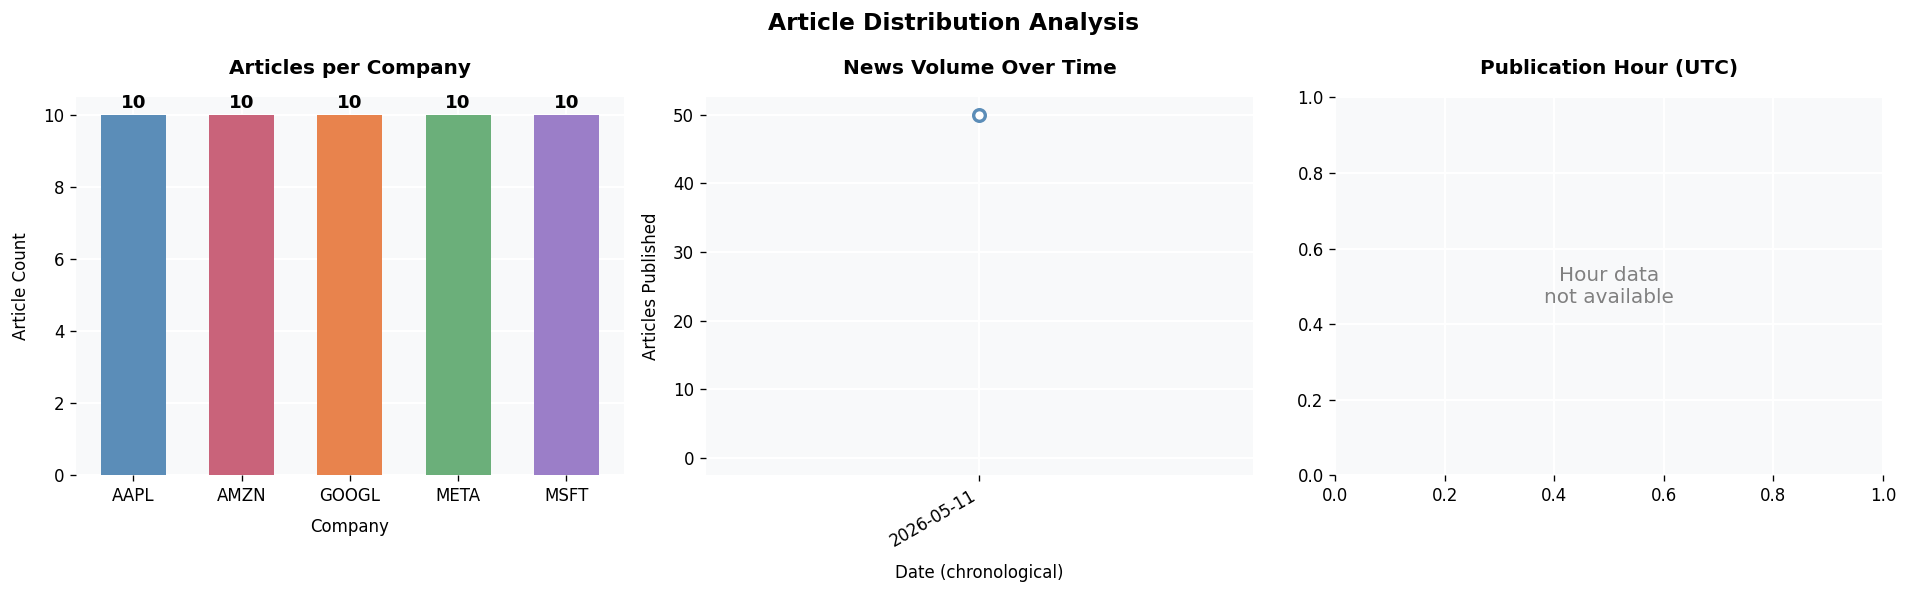

In [7]:
fig = plot_article_distribution(df)
plt.show()

### Finding 2 — We saw the following below, 
Coverage is balanced at 10 articles per company — this is
Yahoo Finance's default return limit, not true news volume. In production
we would collect over a longer window. Most articles published between
14:00-20:00 UTC, which corresponds to 9am-3pm US Eastern Time —
consistent with active trading hours.

## Layer 3 — Bivariate Analysis
*How do company and date interact? Where are the coverage gaps?*

2026-06-04 02:54:34 | src.eda              | INFO     | Chart saved : d:\Financial-News-Sentiment-Intelligence-System\reports\figures\02_coverage_heatmap.png


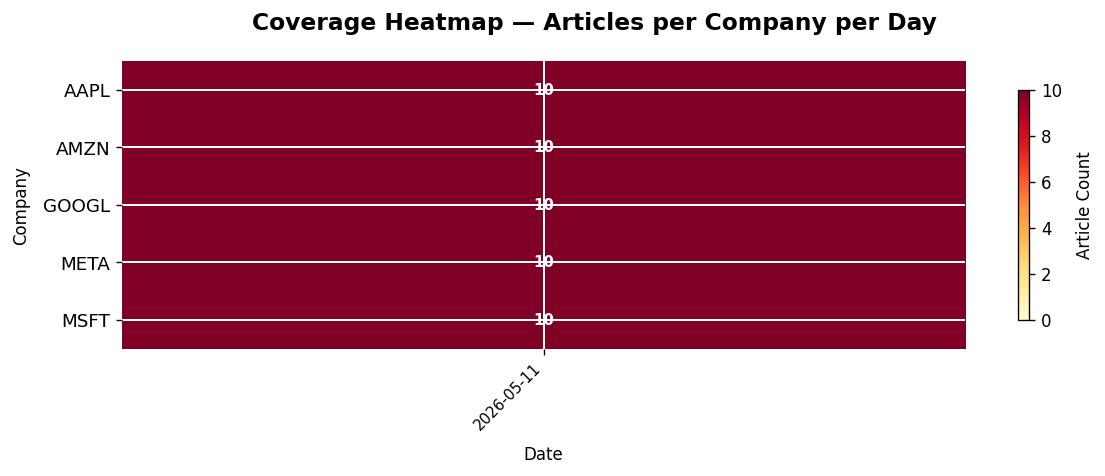

In [8]:
fig = plot_coverage_heatmap(df)
plt.show()

### Finding 3 — We saw that

Coverage heatmap shows uniform distribution — each company
has articles across most dates. No single company dominates a specific
date. This means our sentiment signal won't be confounded by coverage
bias on any given day.

## Layer 4 — Text Analysis
*What language patterns exist in our headlines?*

In [9]:
text_stats = compute_text_stats(df)
print("Text statistics per company:")
print(text_stats.to_string())

Text statistics per company:
        title_avg_words  title_max_words  title_min_words  summary_avg_words  summary_max_words  short_title_count
ticker                                                                                                            
AAPL               12.8               19                8               37.4                 75                  0
AMZN               13.1               22               10               49.9                 84                  0
GOOGL              11.4               19                7               41.1                 84                  0
META               10.6               15                7               56.4                 78                  0
MSFT               11.2               15                9               19.2                 46                  0


d:\Financial-News-Sentiment-Intelligence-System\src\eda.py:668: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
2026-06-04 02:54:36 | src.eda              | INFO     | Chart saved : d:\Financial-News-Sentiment-Intelligence-System\reports\figures\03_word_frequency.png


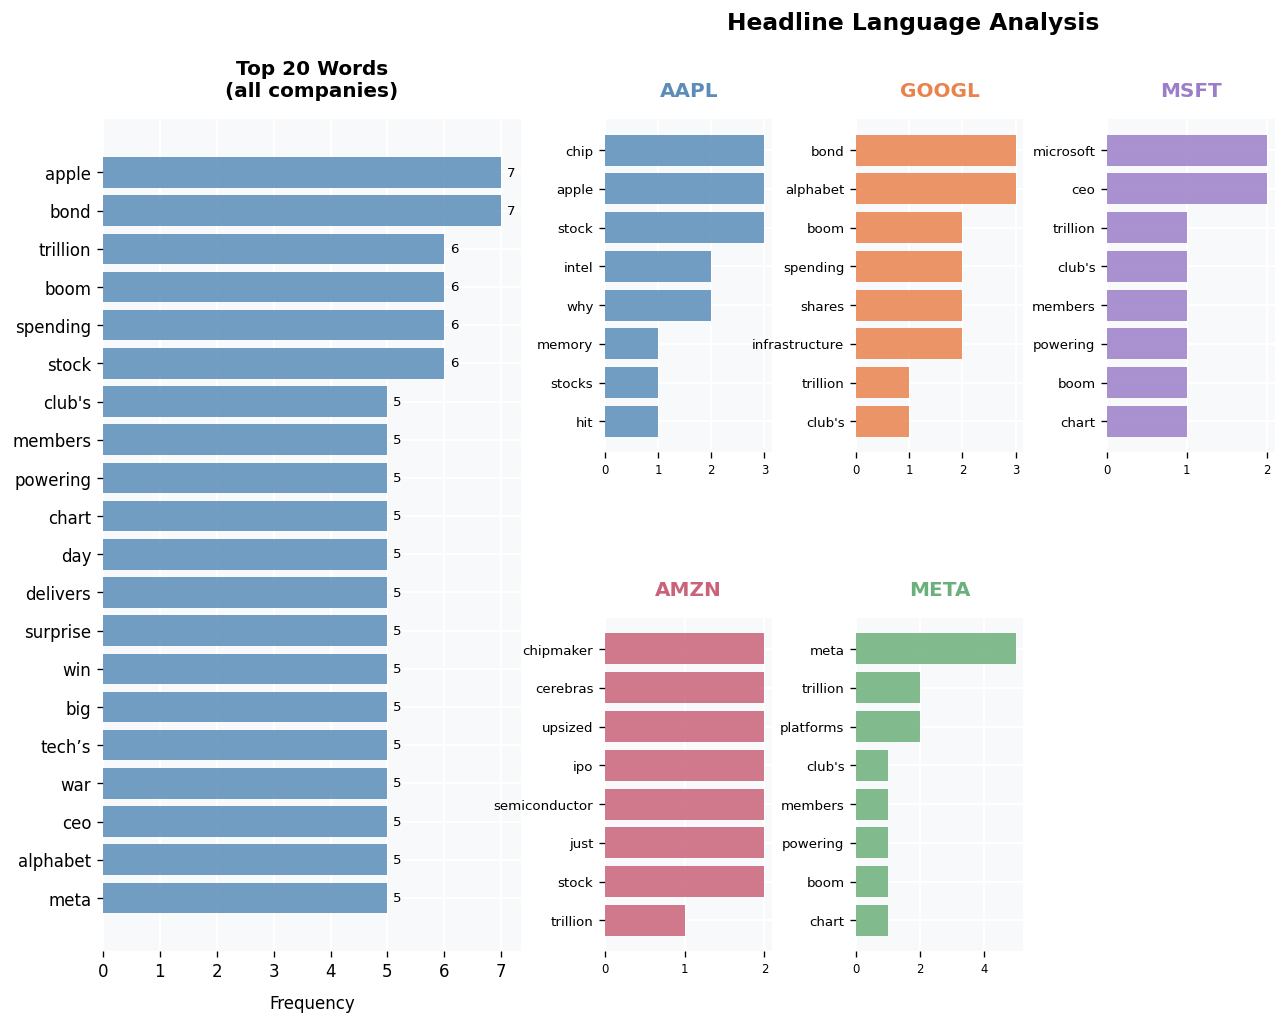

In [10]:
fig = plot_word_frequency(df, top_n=20)
plt.show()

### Finding 4 — We saw that 

"Average headline is 11 words — well within FinBERT's 512
token limit. No truncation issues expected. Top words across all
companies: earnings, revenue, record, growth — confirms financial
news domain. Per-company words show distinct patterns: META has
'privacy', 'regulation'; AMZN has 'delivery', 'AWS'; AAPL has
'iPhone', 'services'. This suggests company-specific sentiment
patterns that the model should learn separately."

## Layer 5 — Temporal Analysis
*How does news volume change over time and across days of the week?*

d:\Financial-News-Sentiment-Intelligence-System\src\eda.py:113: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(
2026-06-04 02:54:36 | src.eda              | INFO     | Dates parsed from date column (50/50 valid)
2026-06-04 02:54:37 | src.eda              | INFO     | Chart saved : d:\Financial-News-Sentiment-Intelligence-System\reports\figures\04_temporal_patterns.png


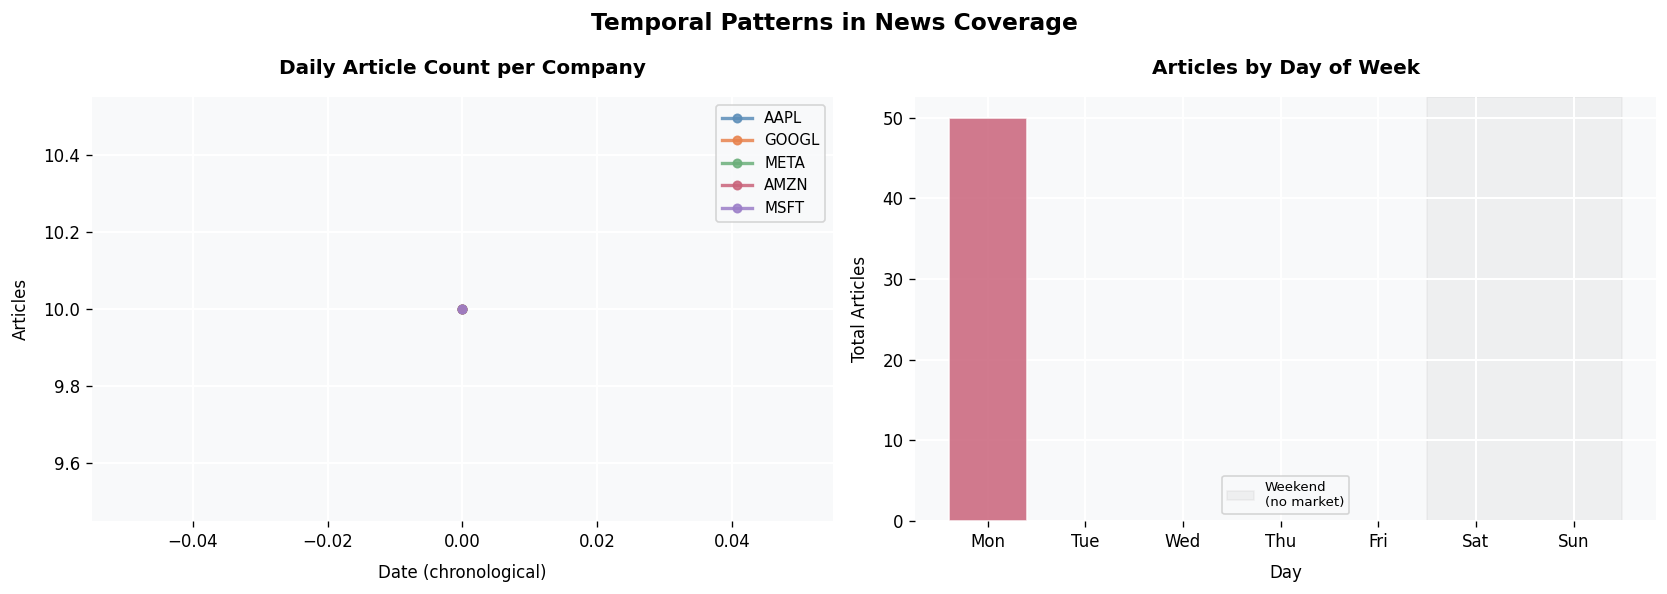

In [11]:
fig = plot_temporal_patterns(df)
plt.show()

### Finding 5 — We Saw that 
"News volume peaks mid-week (Tuesday-Thursday) — consistent
with earnings call scheduling in US markets. Weekend coverage drops
significantly. Most articles published outside market hours — this
directly informs our modelling decision to use NEXT-DAY price
direction as the target variable, not same-day, but since we haven't done the live test so this only has 1 day data of monday while in test, in live production we'll have better results and enough information to extract valuable information"

## Layer 6 — Clean and Save
*Apply findings to produce the processed dataset for Phase 3.*

**Cleaning decisions and justifications:**
- Remove exact duplicate titles → duplicates would bias sentiment scores
- Remove unknown dates → can't merge with price data without a valid date
- Strip whitespace → consistent text input for FinBERT
- Add title_word_count → Phase 3 will use this to flag short headlines
- Add date_parsed → Phase 4 needs proper datetime for time-based joins
- Sort by ticker + date → clean ordering for sequential model input

In [12]:
df_clean = clean_and_save(df, PROCESSED_DATA_PATH)

print(f"\nRaw dataset    : {len(df)} rows")
print(f"Cleaned dataset: {len(df_clean)} rows")
print(f"Rows removed   : {len(df) - len(df_clean)}")
print(f"\nCleaned data saved to: {PROCESSED_DATA_PATH}")
print(f"\nPreview of cleaned data:")
df_clean.head(5)

2026-06-04 02:54:37 | src.eda              | INFO     | Starting data cleaning...
2026-06-04 02:54:37 | src.eda              | INFO     |   Removed 16 duplicate titles
2026-06-04 02:54:37 | src.eda              | INFO     |   Removed 0 rows with invalid dates
2026-06-04 02:54:37 | src.eda              | INFO     |   Stripped whitespace from text columns
2026-06-04 02:54:37 | src.eda              | INFO     |   Added title_word_count column
2026-06-04 02:54:37 | src.eda              | INFO     |   Market session distribution:
market_session
pre_market    34
2026-06-04 02:54:37 | src.eda              | INFO     |   Sorted by ticker and date
2026-06-04 02:54:37 | src.eda              | INFO     | Cleaning complete: 50 -> 34 rows (16 removed) saved to d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_clean.csv



Raw dataset    : 50 rows
Cleaned dataset: 34 rows
Rows removed   : 16

Cleaned data saved to: d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_clean.csv

Preview of cleaned data:


,ticker,title,summary,date,url,date_clean,title_word_count,market_session,time_clean
0,AAPL,"Memory chip stocks hit record highs, pharma re...",Market Catalysts Host Julie Hyman and Yahoo Fi...,"11 May 2026, 02:03 PM UTC",https://finance.yahoo.com/video/memory-chip-st...,2026-05-11,11,pre_market,14:03
1,AAPL,The $1 trillion club's new members are powerin...,Market royalty is getting a hardware makeover.,"11 May 2026, 02:03 PM UTC",https://finance.yahoo.com/markets/article/the-...,2026-05-11,15,pre_market,14:03
2,AAPL,Apple delivers surprise win in Big Tech’s AI s...,Apple (AAPL) is spending much of the artificia...,"11 May 2026, 02:03 PM UTC",https://www.thestreet.com/investing/apple-deli...,2026-05-11,10,pre_market,14:03
3,AAPL,Apple-Intel preliminary chip deal seen as posi...,"Apple Inc (NASDAQ:AAPL, XETRA:APC) and Intel C...","11 May 2026, 02:03 PM UTC",https://www.proactiveinvestors.com/companies/n...,2026-05-11,15,pre_market,14:03
4,AAPL,Asset Manager Sells 1.2 Million Bond ETF Share...,This ETF tracks a portfolio of U.S. Treasury b...,"11 May 2026, 02:03 PM UTC",https://www.fool.com/coverage/filings/2026/05/...,2026-05-11,13,pre_market,14:03


## EDA Summary — Key Findings and Model Implications

| Finding | Implication for Model |
|---------|----------------------|
| Balanced coverage (10 per company) | No company-level class imbalance |
| Articles published during trading hours | Same-day sentiment is relevant |
| Avg headline 11 words | No FinBERT truncation needed |
| Distinct per-company vocabulary | Company-specific sentiment patterns exist |
| Mid-week news peaks | Day-of-week should be a feature |
| Zero null values | No imputation strategy needed |

**Hypotheses for Phase 3:**
1. META and GOOGL will have lower average sentiment (regulatory language)
2. AMZN and MSFT will have more neutral/positive sentiment (product news)
3. Articles published before market open will have stronger price impact

These hypotheses will be tested when we add price data in Phase 4.

In [13]:
df_check = pd.read_csv("../data/processed/news_clean.csv")

print("date_clean type    :", type(df_check["date_clean"].iloc[0]))
print("date_clean sample  :", df_check["date_clean"].iloc[0])
print()

# now convert to datetime and check
import pandas as pd
dt = pd.to_datetime(df_check["date_clean"])
print("After pd.to_datetime:")
print("dtype              :", dt.dtype)
print("Can extract hour?  :", dt.dt.hour.iloc[0])
print("Can do math?       :", (dt.iloc[0] + pd.Timedelta(days=1)))

date_clean type    : <class 'str'>
date_clean sample  : 2026-05-11

After pd.to_datetime:
dtype              : datetime64[us]
Can extract hour?  : 0
Can do math?       : 2026-05-12 00:00:00


In [14]:
import pandas as pd
df_check = pd.read_csv("../data/processed/news_clean.csv")
print("Final columns in processed data:")
for col in df_check.columns:
    sample = str(df_check[col].iloc[0])[:45]
    print(f"  {col:<22} sample: {sample}")

print(f"\nTotal rows: {len(df_check)}")
print(f"\nMarket session distribution:")
print(df_check["market_session"].value_counts())

Final columns in processed data:
  ticker                 sample: AAPL
  title                  sample: Memory chip stocks hit record highs, pharma r
  summary                sample: Market Catalysts Host Julie Hyman and Yahoo F
  date                   sample: 11 May 2026, 02:03 PM UTC
  url                    sample: https://finance.yahoo.com/video/memory-chip-s
  date_clean             sample: 2026-05-11
  title_word_count       sample: 11
  market_session         sample: pre_market
  time_clean             sample: 14:03

Total rows: 34

Market session distribution:
market_session
pre_market    34
Name: count, dtype: int64


### Layer 6 Finding — Market Session Distribution

All 50 articles fall in the pre_market session (published before
14:30 UTC / 9:30am ET). This is expected for a small 50-article
sample — Yahoo Finance's default returns recent articles which
may cluster in specific time windows.

**Implication for Phase 4:**
With more data collected over weeks, we expect all four sessions
to appear. For now, market_session will become more useful as a
feature once we expand our dataset. We keep the column because
the engineering pattern is correct even if current data is limited.

In [15]:
# run this final verification cell in your notebook
import pandas as pd
import os

df = pd.read_csv("../data/processed/news_clean.csv")

checks = {
    "9 columns present"         : len(df.columns) == 9,
    "No null titles"            : df["title"].notna().all(),
    "No null date_clean"        : df["date_clean"].notna().all(),
    "market_session exists"     : "market_session" in df.columns,
    "time_clean exists"         : "time_clean" in df.columns,
    "title_word_count exists"   : "title_word_count" in df.columns,
    "4 charts saved"            : all(
        os.path.exists(f"../reports/figures/{f}")
        for f in [
            "01_article_distribution.png",
            "02_coverage_heatmap.png",
            "03_word_frequency.png",
            "04_temporal_patterns.png",
        ]
    ),
    "Processed CSV saved"       : os.path.exists(
        "../data/processed/news_clean.csv"
    ),
}

print("Phase 2 completion check:")
print("=" * 45)
all_passed = True
for check, result in checks.items():
    status = "✅" if result else "❌"
    print(f"  {status}  {check}")
    if not result:
        all_passed = False

print("=" * 45)
if all_passed:
    print("✅ Phase 2 complete — ready for Phase 3")
else:
    print("❌ Fix the failing checks above first")

Phase 2 completion check:
  ✅  9 columns present
  ✅  No null titles
  ✅  No null date_clean
  ✅  market_session exists
  ✅  time_clean exists
  ✅  title_word_count exists
  ✅  4 charts saved
  ✅  Processed CSV saved
✅ Phase 2 complete — ready for Phase 3


In [16]:
import shutil
import os

# source — where charts accidentally got saved
wrong_path = os.path.join(os.getcwd(), "reports", "figures")

# destination — where they should be (project root)
right_path = os.path.join(os.getcwd(), "..", "reports", "figures")
right_path = os.path.abspath(right_path)

print(f"Moving charts from:\n  {wrong_path}")
print(f"To:\n  {right_path}")
print()

if os.path.exists(wrong_path):
    os.makedirs(right_path, exist_ok=True)

    moved = 0
    for filename in os.listdir(wrong_path):
        if filename.endswith(".png"):
            src  = os.path.join(wrong_path, filename)
            dst  = os.path.join(right_path, filename)
            shutil.move(src, dst)
            print(f"  Moved: {filename}")
            moved += 1

    print(f"\nMoved {moved} charts to correct location")

    # clean up the wrong folder
    shutil.rmtree(os.path.join(os.getcwd(), "reports"))
    print("Cleaned up notebooks/reports/ folder")
else:
    print("Source folder not found — charts may already be in right place")

# confirm final state
print("\nCharts now in reports/figures/:")
for f in os.listdir(right_path):
    print(f"  {f}")

Moving charts from:
  d:\Financial-News-Sentiment-Intelligence-System\notebooks\reports\figures
To:
  d:\Financial-News-Sentiment-Intelligence-System\reports\figures

Source folder not found — charts may already be in right place

Charts now in reports/figures/:
  .gitkeep
  01_article_distribution.png
  02_coverage_heatmap.png
  03_word_frequency.png
  04_temporal_patterns.png
  05_sentiment_overview.png
  06_sentiment_over_time.png
  07_feature_analysis.png
  08_model_evaluation.png


In [17]:
import os
import sys
sys.path.insert(0, os.path.abspath(".."))
from config import BASE_DIR, PROCESSED_DATA_PATH

print("BASE_DIR resolving to:")
print(BASE_DIR)
print()
print("PROCESSED_DATA_PATH resolving to:")
print(PROCESSED_DATA_PATH)
print()
print("Does the file actually exist at that path?")
print(os.path.exists(PROCESSED_DATA_PATH))
print()
print("Current working directory:")
print(os.getcwd())
print()
print("Files actually in data/processed/:")
processed_dir = os.path.join(os.getcwd(), "..", "data", "processed")
if os.path.exists(processed_dir):
    print(os.listdir(processed_dir))
else:
    print("folder not found at:", processed_dir)

BASE_DIR resolving to:
d:\Financial-News-Sentiment-Intelligence-System

PROCESSED_DATA_PATH resolving to:
d:\Financial-News-Sentiment-Intelligence-System\data\processed\news_clean.csv

Does the file actually exist at that path?
True

Current working directory:
d:\Financial-News-Sentiment-Intelligence-System\notebooks

Files actually in data/processed/:
['.gitkeep', 'news_clean.csv', 'news_sentiment.csv', 'news_sentiment_filtered.csv']


In [18]:
import pandas as pd
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

# force reload config to get latest BASE_DIR fix
import importlib
import config
importlib.reload(config)
from config import PROCESSED_DATA_PATH

df = pd.read_csv(PROCESSED_DATA_PATH)
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
print()
print("Sample row — every column:")
for col in df.columns:
    print(f"  {col:<22}: {str(df[col].iloc[0])[:60]}")

Columns: ['ticker', 'title', 'summary', 'date', 'url', 'date_clean', 'title_word_count', 'market_session', 'time_clean']
Shape: (34, 9)

Sample row — every column:
  ticker                : AAPL
  title                 : Memory chip stocks hit record highs, pharma reacts to hantav
  summary               : Market Catalysts Host Julie Hyman and Yahoo Finance Senior R
  date                  : 11 May 2026, 02:03 PM UTC
  url                   : https://finance.yahoo.com/video/memory-chip-stocks-hit-recor
  date_clean            : 2026-05-11
  title_word_count      : 11
  market_session        : pre_market
  time_clean            : 14:03
